In [3]:
import dgl
import torch
from torch_geometric.data import HeteroData
from torch_geometric.utils import from_networkx
import networkx as nx

# 读取 DGL 图
graph_path = "input_data/hetero_graph.bin"
g, _ = dgl.load_graphs(graph_path)
g = g[0]  # 只取第一个图

# 初始化 PyG 的 HeteroData
pyg_data = HeteroData()

# 节点特征赋值
for ntype in g.ntypes:
    pyg_data[ntype].x = g.nodes[ntype].data['feat']

# 边构造
for srctype, etype, dsttype in g.canonical_etypes:
    src, dst = g.edges(etype=(srctype, etype, dsttype))
    pyg_data[(srctype, etype, dsttype)].edge_index = torch.stack([src, dst], dim=0)

# 标签与掩码加载
label_data = torch.load("input_data/label_mask.pt")
pyg_data['protein'].y = label_data['labels']
mask_idx = label_data['mask_idx']
train_mask = torch.zeros_like(pyg_data['protein'].y, dtype=torch.bool)
train_mask[mask_idx] = True
pyg_data['protein'].train_mask = train_mask

In [69]:
import torch
import torch.nn as nn
from torch_geometric.nn import HGTConv

class HGTModel(nn.Module):
    def __init__(self, metadata, in_channels, hidden_channels, out_channels, num_layers=2, heads=2):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(num_layers):
            self.layers.append(HGTConv(
                in_channels if i == 0 else hidden_channels,
                hidden_channels,
                metadata,
                heads=heads
            ))
        self.out_proj = nn.Linear(hidden_channels, out_channels)

    def forward(self, x_dict, edge_index_dict):
        for layer in self.layers:
            x_dict = layer(x_dict, edge_index_dict)
        return {"protein": self.out_proj(x_dict['protein'])}

# === 加载模型和分类器 ===
hgt_checkpoint = torch.load("./cv_results_hgt/fold_7/best_model.pt") #4,7

hgt_model = HGTModel(
    metadata=pyg_data.metadata(),
    in_channels=150,
    hidden_channels=90,
    out_channels=90,
    num_layers=2,
    heads=2
)
hgt_classifier = NodeClassifier(embed_dim=90, num_classes=2) 
hgt_model.load_state_dict(hgt_checkpoint['model'])
hgt_classifier.load_state_dict(hgt_checkpoint['classifier'])

<All keys matched successfully>

In [1]:
import torch
import json
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
import numpy as np
import pandas as pd
from emhgnn import EmhGNNGraph,NodeClassifier
import dgl

# === 加载异构图 ===
# 读取 DGL 图
graph_path = "input_data/hetero_graph.bin"
g, _ = dgl.load_graphs(graph_path)
g=g[0]

feat_dict = {
    ntype: g.nodes[ntype].data['feat'].float()
    for ntype in g.ntypes
}
# 加载标签和掩码
data = torch.load("input_data/label_mask.pt")
labels = data["labels"].cpu().numpy()
mask_idx = data["mask_idx"].cpu().numpy()

with open('input_data/all_gene_names.json', 'r') as f:
    name = json.load(f)

protein_names = name['protein']



In [ ]:
#10折平均结果汇总
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_line_raw = pd.read_csv("./cv_results_dw_line_concat/dw_test_probs.csv")
df_dw_raw = pd.read_csv("./cv_results_dw_line_concat/line_test_probs.csv")


def build_df(probs_or_scores, labels, model_name):
    scores = probs_or_scores.flatten()
    return pd.DataFrame({
        "Confidence score": scores,
        "Label": ["Cancer gene" if l == 1 else "Non-cancer gene" for l in labels],
        "Model": model_name
    })

def load_10fold_avg(base_dir, file_name="test_probs.csv", prob_col="prob"):
    """
    读取一个模型10折 test_probs 文件并对 prob 做按节点平均
    返回: 平均后的 prob numpy 数组（顺序按第一次读到的文件）
    """
    all_probs = []
    index_ref = None

    for fold in range(1, 11):
        path = os.path.join(base_dir, f"fold_{fold}", file_name)
        df = pd.read_csv(path)

        if index_ref is None:
            index_ref = df.index
        else:
            df = df.loc[index_ref]

        all_probs.append(df[prob_col].values)

    all_probs = np.stack(all_probs, axis=0)   # [10, N]
    mean_probs = np.mean(all_probs, axis=0)   # [N]

    return mean_probs

def load_mradiff_10fold_avg_bestfold(
    base_dir="../seed51/full",
    prob_col="prob_cancer",
    label_col="label",
    fold_ids=range(10)   
):
    probs_list = []
    labels_ref = None

    for k in fold_ids:
        path = os.path.join(base_dir, f"best_fold{k}_all_protein_predictions.csv")
        df = pd.read_csv(path)

        # 只保留有标签的行（label != -1）
        df = df[df[label_col] != -1].copy()

        # 保险：保证每折顺序一致（如果有 protein_id 列就按它对齐）
        if "protein_id" in df.columns:
            df = df.sort_values("protein_id").reset_index(drop=True)

        if labels_ref is None:
            labels_ref = df[label_col].values
        else:
            # 确保标签一致（防止不同折 test 集不一致导致错位）
            if not np.array_equal(labels_ref, df[label_col].values):
                raise ValueError(
                    f"[MRADiff] fold{k} 的标签序列与其他fold不一致。"
                    f"请确认每个 best_fold{k} 文件对应同一批 test 节点，或提供 protein_id 用于严格对齐。"
                )

        probs_list.append(df[prob_col].values)

    probs_mat = np.stack(probs_list, axis=0)     # [K, N]
    mean_probs = probs_mat.mean(axis=0)          # [N]
    return mean_probs, labels_ref

# === 生成 df_mradiff（变量名不变）===
mradiff_mean_probs, mradiff_labels = load_mradiff_10fold_avg_bestfold(
    base_dir="../seed51/full",
    prob_col="prob_cancer",
    label_col="label",
    fold_ids=range(10)  # 0~9
)
df_mradiff = build_df(mradiff_mean_probs, mradiff_labels, "MRAGDM")
hgt_probs = load_10fold_avg(
    base_dir="./result/cv_results_hgt",
    prob_col="prob"
)

df_line = build_df(df_line_raw["score"].values, df_line_raw["label"].values, "LINE")
df_dw = build_df(df_dw_raw["score"].values, df_dw_raw["label"].values, "DeepWalk")

df_hgt = build_df(hgt_probs[mask_idx], labels[mask_idx], "HGT")

han_probs = load_10fold_avg(
    base_dir="./result/cv_results_han",
    prob_col="prob"
)

df_han = build_df(han_probs[mask_idx], labels[mask_idx], "HAN")

rgcn_probs = load_10fold_avg(
    base_dir="./result/cv_results_rgcn",
    prob_col="prob"
)

df_rgcn = build_df(rgcn_probs[mask_idx], labels[mask_idx], "RGCN")

def load_10fold_avg_emogi(base_dir):
    dfs = []
    for fold in range(10):
        path = os.path.join(base_dir, f"cv_{fold}", "test_probs_emogi_matched.csv")
        df = pd.read_csv(path)
        df["protein"] = df["protein"].str.strip().str.upper()
        dfs.append(df)

    # 以第一折为基准
    base = dfs[0][["protein"]].copy()
    prob_matrix = []

    for df in dfs:
        df = df.set_index("protein")
        prob_matrix.append(df.loc[base["protein"], "prob_emogi"].values)

    prob_matrix = np.stack(prob_matrix, axis=0)
    mean_probs = np.mean(prob_matrix, axis=0)

    base["prob_emogi"] = mean_probs
    return base

df_emogi_raw = load_10fold_avg_emogi("./emogi/2025_07_20_21_39_51")
# === 先加载 drivers / nondrivers ===
drivers = set(pd.read_csv("./input_data/796_drivers.txt", header=None)[0].str.strip().str.upper())
nondrivers = set(pd.read_csv("./input_data/2187_nondrivers.txt", header=None)[0].str.strip().str.upper())
df_emogi_raw["Label"] = df_emogi_raw["protein"].apply(
    lambda g: "Cancer gene" if g in drivers else (
        "Non-cancer gene" if g in nondrivers else None)
)

df_emogi = df_emogi_raw.dropna(subset=["Label"]).copy()
df_emogi = df_emogi.rename(columns={"prob_emogi": "Confidence score"})
df_emogi["Model"] = "EMOGI"

df_all = pd.concat(
    [df_dw, df_line, df_emogi, df_rgcn, df_han, df_hgt, df_mradiff],
    axis=0,
    ignore_index=True
)


/root/miniconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_2006/1038373868.py:240: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


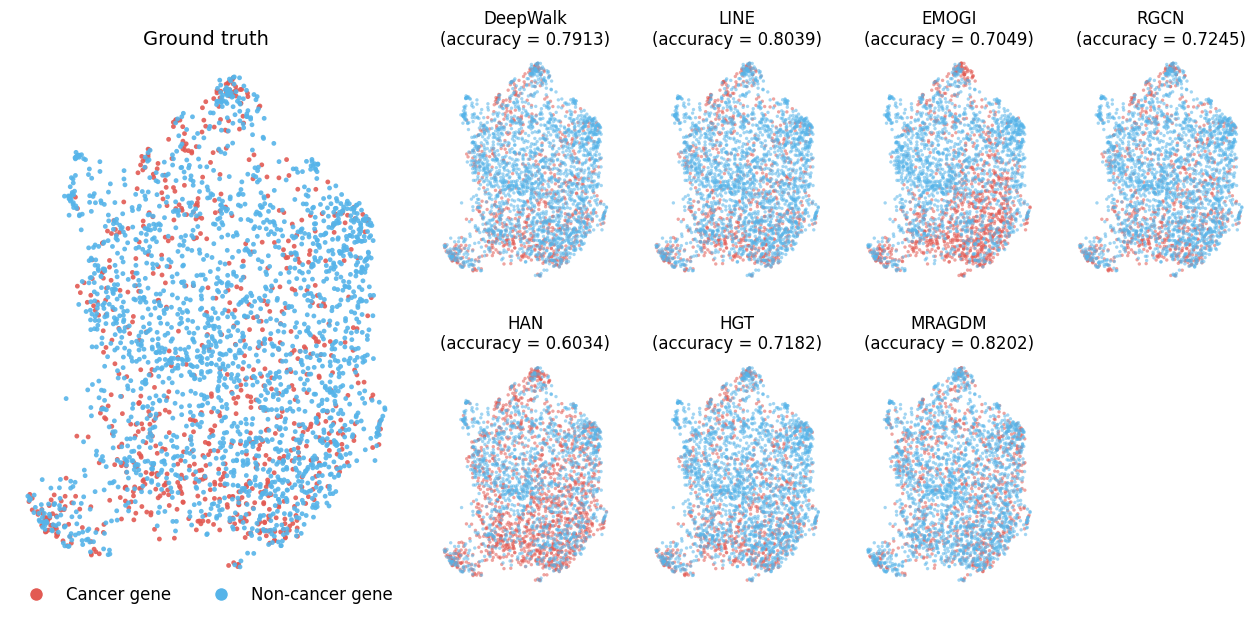

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import torch
import dgl
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import umap

# =========================
# 0) 读 DGL 图 + 读标签掩码 + 读 gene name 映射
# =========================
graph_path = "input_data/hetero_graph.bin"
g, _ = dgl.load_graphs(graph_path)
g = g[0]

# protein 150维特征
X = g.nodes["protein"].data["feat"].float().cpu().numpy()   # [N_protein, 150]

# 标签与掩码
data = torch.load("input_data/label_mask.pt")
labels = data["labels"].cpu().numpy()       # [N_protein]
mask_idx = data["mask_idx"].cpu().numpy()   # 有标签蛋白索引（protein_id）

# gene name 映射
with open("input_data/all_gene_names.json", "r") as f:
    name = json.load(f)
protein_names = name["protein"]  # list, len=N_protein，一般为基因符号

# 建立 gene_symbol -> protein_id 的字典（统一大写 & 去空格）
name2pid = {str(g).strip().upper(): i for i, g in enumerate(protein_names)}

# ground truth 标签（只取有标签蛋白）
y_true = labels[mask_idx].astype(int)  # 0/1

# =========================
# 1) 用 150维特征做 2D 坐标（UMAP）
# =========================
X_labeled = X[mask_idx]  # 只对有标签蛋白降维
X_labeled_std = StandardScaler().fit_transform(X_labeled)

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=50,
    min_dist=0.15,
    metric="cosine",
    random_state=0
)
xy = reducer.fit_transform(X_labeled_std)   # [N_labeled, 2]


# =========================
# 2) 确保 df_all 内各模型都有 protein_id 列（关键）
#    前面已经生成了 df_dw/df_line/df_rgcn/df_han/df_hgt/df_mradiff/df_emogi
#    这里做统一对齐和补齐 protein_id
# =========================

# ---- 2.1 非 EMOGI 的模型：使用的是用 mask_idx 顺序生成的概率
#      所以直接塞 protein_id = mask_idx
for _df in [df_dw, df_line, df_rgcn, df_han, df_hgt, df_mradiff]:
    _df["protein_id"] = mask_idx


# ---- 2.2 EMOGI：做 gene symbol -> protein_id 映射，并过滤到 mask_idx 这批蛋白
drivers = set(pd.read_csv("./input_data/796_drivers.txt", header=None)[0].str.strip().str.upper())
nondrivers = set(pd.read_csv("./input_data/2187_nondrivers.txt", header=None)[0].str.strip().str.upper())

# df_emogi_raw 包含: protein, prob_emogi
df_emogi_raw["protein"] = df_emogi_raw["protein"].astype(str).str.strip().str.upper()

df_emogi_raw["Label"] = df_emogi_raw["protein"].apply(
    lambda g: "Cancer gene" if g in drivers else ("Non-cancer gene" if g in nondrivers else None)
)
df_emogi = df_emogi_raw.dropna(subset=["Label"]).copy()
df_emogi = df_emogi.rename(columns={"prob_emogi": "Confidence score"})
df_emogi["Model"] = "EMOGI"

# === EMOGI 映射到 protein_id ===
df_emogi["protein_id"] = df_emogi["protein"].map(name2pid)

# 去掉无法映射到图节点的
df_emogi = df_emogi.dropna(subset=["protein_id"]).copy()
df_emogi["protein_id"] = df_emogi["protein_id"].astype(int)

# 只保留在 mask_idx 的那批有标签蛋白（保证与 xy 完全同一批点）
mask_set = set(mask_idx.tolist())
df_emogi = df_emogi[df_emogi["protein_id"].isin(mask_set)].copy()

# 再确保每个 protein_id 只有一个分数（如果有重复，取均值）
df_emogi = df_emogi.groupby(["protein_id", "Model"], as_index=False)["Confidence score"].mean()

# =========================
# 3) 汇总 df_all（防止重复index引起 seaborn/pandas 错误）
# =========================
df_all = pd.concat(
    [df_dw, df_line, df_emogi, df_rgcn, df_han, df_hgt, df_mradiff],
    axis=0,
    ignore_index=True
)

# 清洗数值列（保险）
df_all["Confidence score"] = pd.to_numeric(df_all["Confidence score"], errors="coerce")
df_all = df_all.dropna(subset=["Confidence score", "Model", "protein_id"])


# =========================
# 4) 函数：从 df_all 取某模型概率并按 mask_idx 对齐
# =========================
def get_model_prob_aligned(df_all, model_name, mask_idx):
    dfm = df_all[df_all["Model"] == model_name][["protein_id", "Confidence score"]].copy()

    # 可能出现同一 protein_id 多行，做一次聚合
    dfm = dfm.groupby("protein_id", as_index=True)["Confidence score"].mean()

    # 对齐到 mask_idx（只取有标签蛋白，并按 mask_idx 顺序）
    # 若有缺失，就填 NaN，后面可以选择丢弃或填0.5
    prob = dfm.reindex(mask_idx).values
    return prob


# =========================
# 5) 左 Ground truth，右多模型面板
# =========================
def plot_panel(ax, xy, y01, title, s=4, alpha0=0.55, alpha1=0.8):
    ax.scatter(xy[y01 == 0, 0], xy[y01 == 0, 1], s=s, alpha=alpha0)
    ax.scatter(xy[y01 == 1, 0], xy[y01 == 1, 1], s=s, alpha=alpha1)
    ax.set_title(title, fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

# ======== 要展示的模型顺序 ========
models_show = ["DeepWalk", "LINE", "EMOGI",
               "RGCN", "HAN", "HGT", "MRAGDM"]

# ======== Accuracy 字典 ========
acc_dict = {
    "DeepWalk": 0.7913,
    "LINE": 0.8039,
    "EMOGI": 0.7049,
    "RGCN": 0.7245,
    "HAN": 0.6034,
    "HGT": 0.7182,
    "MRAGDM": 0.8202
}


COLOR_CANCER = "#E25A53"
COLOR_NON = "#56B4E9"#E8DCB9"

# 点大小参数
S_GT = 12        # Ground truth 稍大
S_MODEL = 6      # 模型子图小一点

ALPHA_GT = 0.9
ALPHA_MODEL = 0.55   # 降低透明度避免糊

fig = plt.figure(figsize=(16, 7))
gs = fig.add_gridspec(2, 5,
                      width_ratios=[2.2, 1, 1, 1, 1],
                      wspace=0.15, hspace=0.3)

# ================= Ground truth =================
ax0 = fig.add_subplot(gs[:, 0])

ax0.scatter(xy[y_true==1,0], xy[y_true==1,1],
            s=S_GT, alpha=ALPHA_GT,
            color=COLOR_CANCER, edgecolors="none")

ax0.scatter(xy[y_true==0,0], xy[y_true==0,1],
            s=S_GT, alpha=ALPHA_GT,
            color=COLOR_NON, edgecolors="none")

ax0.set_title("Ground truth", fontsize=14)
ax0.set_xticks([]); ax0.set_yticks([])
for s in ax0.spines.values():
    s.set_visible(False)

# ====== 大一点的图例 ======
legend_handles = [
    plt.Line2D([0],[0], marker='o', color='w',
               markerfacecolor=COLOR_CANCER,
               markersize=10, label="Cancer gene"),
    plt.Line2D([0],[0], marker='o', color='w',
               markerfacecolor=COLOR_NON,
               markersize=10, label="Non-cancer gene")
]

ax0.legend(handles=legend_handles,
           loc="lower center",
           bbox_to_anchor=(0.5, -0.05),
           frameon=False,
           ncol=2,
           fontsize=12)

# ================= 右侧模型 =================
axes = [
    fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[0, 2]),
    fig.add_subplot(gs[0, 3]), fig.add_subplot(gs[0, 4]),
    fig.add_subplot(gs[1, 1]), fig.add_subplot(gs[1, 2]),
    fig.add_subplot(gs[1, 3])
]

for ax, m in zip(axes, models_show):
    prob = get_model_prob_aligned(df_all, m, mask_idx)
    ok = ~np.isnan(prob)

    xy_ok = xy[ok]
    y_pred = (prob[ok] >= 0.5).astype(int)

    ax.scatter(xy_ok[y_pred==1,0], xy_ok[y_pred==1,1],
               s=S_MODEL,
               alpha=ALPHA_MODEL,
               color=COLOR_CANCER,
               edgecolors="none")

    ax.scatter(xy_ok[y_pred==0,0], xy_ok[y_pred==0,1],
               s=S_MODEL,
               alpha=ALPHA_MODEL,
               color=COLOR_NON,
               edgecolors="none")

    ax.set_title(f"{m}\n(accuracy = {acc_dict[m]:.4f})",
                 fontsize=12)

    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)

plt.tight_layout()
plt.savefig("../figure/umap_51.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()



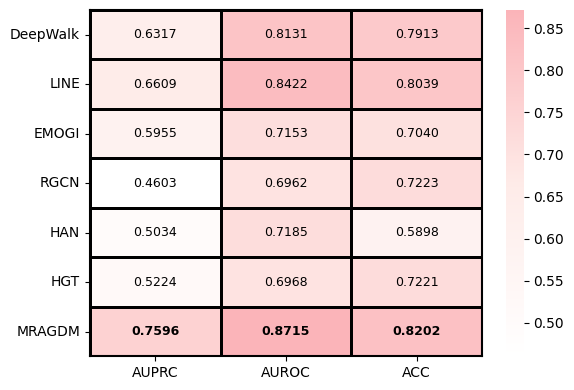

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json,os,re
import numpy as np

# === 1. 读取各模型结果 ===

# DeepWalk
df_dw = pd.read_csv("./result/cv_results_dw_line_concat/test_dw_new.csv")
dw_result = df_dw.iloc[0].round(4).to_dict()

# LINE
df_line = pd.read_csv("./result/cv_results_dw_line_concat/test_line_new.csv")
line_result = df_line.iloc[0].round(4).to_dict()

# RGCN
with open("./result/cv_results_rgcn/final_test_average.json", "r") as f:
    rgcn_result = json.load(f)
rgcn_result = {k.upper(): round(v, 4) for k, v in rgcn_result.items()}

# HAN
with open("./result/cv_results_han/final_test_average.json", "r") as f:
    han_result = json.load(f)
han_result = {k.upper(): round(v, 4) for k, v in han_result.items()}

# HGT
with open("./result/cv_results_hgt/final_test_average.json", "r") as f:
    hgt_result = json.load(f)
hgt_result = {k.upper(): round(v, 4) for k, v in hgt_result.items()}


# === 2. 构建 DataFrame（按顺序排列） ===
model_order = ["DeepWalk", "LINE", "RGCN", "HAN", "HGT", "EmhGNN"]
metrics = ["AUPRC", "AUROC", "ACC", "F1","RECALL"]
result_matrix = [
    [dw_result["AUPRC"], dw_result["AUROC"], dw_result["ACC"], dw_result["F1"],dw_result["Recall"]],
    [line_result["AUPRC"], line_result["AUROC"], line_result["ACC"], line_result["F1"],line_result["Recall"]],
    [rgcn_result["AUPRC"], rgcn_result["AUROC"], rgcn_result["ACCURACY"], rgcn_result["F1"],rgcn_result["RECALL"]],
    [han_result["AUPRC"], han_result["AUROC"], han_result["ACCURACY"], han_result["F1"],han_result["RECALL"]],
    [hgt_result["AUPRC"], hgt_result["AUROC"], hgt_result["ACCURACY"], hgt_result["F1"],hgt_result["RECALL"]]
]
# === 1. 平均值 ===
def load_emogi(base_path):
    acc, auroc, auprc = [], [], []

    for i in range(10):
        path = os.path.join(base_path, f"cv_{i}", "cv_results.txt")
        with open(path, "r") as f:
            text = f.read()

        acc.append(float(re.search(r"accuracy=([0-9.]+)", text).group(1)))
        auprc.append(float(re.search(r"aupr=([0-9.]+)", text).group(1)))
        auroc.append(float(re.search(r"auroc=([0-9.]+)", text).group(1)))

    return {
        "AUPRC": np.mean(auprc),
        "AUROC": np.mean(auroc),
        "ACC": np.mean(acc)
    }
emogi_avg = load_emogi("./result/emogi/2025_07_20_21_39_51")
mradiff_avg = {
    "AUPRC": 0.7596,
    "AUROC": 0.8715,
    "ACC":   0.8202
}   


# === 2. 构造 4×3 结果矩阵 ===
model_order = ["DeepWalk", "LINE", "EMOGI", "RGCN", "HAN", "HGT", "MRAGDM"]
metrics     = ["AUPRC", "AUROC", "ACC"]

result_matrix_emo = [
    [dw_result["AUPRC"],      dw_result["AUROC"],      dw_result["ACC"]],
    [line_result["AUPRC"],    line_result["AUROC"],    line_result["ACC"]],
    [emogi_avg["AUPRC"],      emogi_avg["AUROC"],      emogi_avg["ACC"]],
    [rgcn_result["AUPRC"],    rgcn_result["AUROC"],    rgcn_result["ACCURACY"]],
    [han_result["AUPRC"],     han_result["AUROC"],     han_result["ACCURACY"]],
    [hgt_result["AUPRC"],     hgt_result["AUROC"],     hgt_result["ACCURACY"]],
    [mradiff_avg["AUPRC"],  mradiff_avg["AUROC"],  mradiff_avg["ACC"]],
]
df = pd.DataFrame(result_matrix_emo, index=model_order, columns=metrics)

# === 3. 绘制热图 ===
import numpy as np

plt.figure(figsize=(6, 4))

# === 自定义颜色 ===
from matplotlib.colors import LinearSegmentedColormap
cmap_color = LinearSegmentedColormap.from_list(
    "custom_pink",
    ["#ffffff", "#feebe8", "#fbb4b9"]
)

# === 找每列最大值 ===
df_values = df.values
max_mask = df_values == df_values.max(axis=0)

# === 先画 heatmap（不显示 annot）===
ax = sns.heatmap(
    df,
    annot=False,   # ❗先关掉
    cmap=cmap_color,
    linewidths=1,  # 加粗一点更好看
    linecolor="black",
    cbar=True
)

# === 手动添加文本（实现加粗）===
for i in range(df.shape[0]):
    for j in range(df.shape[1]):
        value = df.iloc[i, j]
        is_max = max_mask[i, j]

        ax.text(
            j + 0.5,
            i + 0.5,
            f"{value:.4f}",
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold" if is_max else "normal"
        )

# === 外边框（关键）===
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color("black")

# === 坐标轴优化 ===
plt.xticks(rotation=0, fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()

plt.savefig(
    "../figure/heatmap_results_MRGAD.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
